In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from svm_visualization import draw_boundary
from players import aaron_judge, jose_altuve, david_ortiz

import warnings
warnings.filterwarnings('ignore')

### Examining the data

In [2]:
print(aaron_judge.columns)

Index(['pitch_type', 'game_date', 'release_speed', 'release_pos_x',
       'release_pos_z', 'player_name', 'batter', 'pitcher', 'events',
       'description', 'spin_dir', 'spin_rate_deprecated',
       'break_angle_deprecated', 'break_length_deprecated', 'zone', 'des',
       'game_type', 'stand', 'p_throws', 'home_team', 'away_team', 'type',
       'hit_location', 'bb_type', 'balls', 'strikes', 'game_year', 'pfx_x',
       'pfx_z', 'plate_x', 'plate_z', 'on_3b', 'on_2b', 'on_1b',
       'outs_when_up', 'inning', 'inning_topbot', 'hc_x', 'hc_y',
       'tfs_deprecated', 'tfs_zulu_deprecated', 'pos2_person_id', 'umpire',
       'sv_id', 'vx0', 'vy0', 'vz0', 'ax', 'ay', 'az', 'sz_top', 'sz_bot',
       'hit_distance_sc', 'launch_speed', 'launch_angle', 'effective_speed',
       'release_spin_rate', 'release_extension', 'game_pk', 'pos1_person_id',
       'pos2_person_id.1', 'pos3_person_id', 'pos4_person_id',
       'pos5_person_id', 'pos6_person_id', 'pos7_person_id', 'pos8_person_id',

In [3]:
print(aaron_judge.description.unique())

['swinging_strike' 'called_strike' 'ball' 'hit_into_play_score' 'foul'
 'blocked_ball' 'hit_into_play' 'hit_into_play_no_out'
 'swinging_strike_blocked' 'foul_tip' 'hit_by_pitch']


'S': Strike, 'B': Ball, 'X': Neither

In [4]:
print(aaron_judge.type.unique())

['S' 'B' 'X']


### Transforming feature 'type' into labels

In [5]:
aaron_judge['type'] = aaron_judge['type'].map({'S': 1, 'B': 0})
print(aaron_judge['type'].unique())

[ 1.  0. nan]


In [6]:
print(aaron_judge['plate_x'])

0       1.0150
1       0.4546
2       0.0957
3       1.5161
4       0.0764
         ...  
2984   -0.3738
2985   -0.2953
2986    1.4094
2987    1.6717
2988   -0.1571
Name: plate_x, Length: 2989, dtype: float64


Drop NaN values for columns 'plate_x', 'plate_y' and 'type'

In [7]:
aaron_judge = aaron_judge.dropna(subset = ['plate_x', 'plate_z', 'type'])

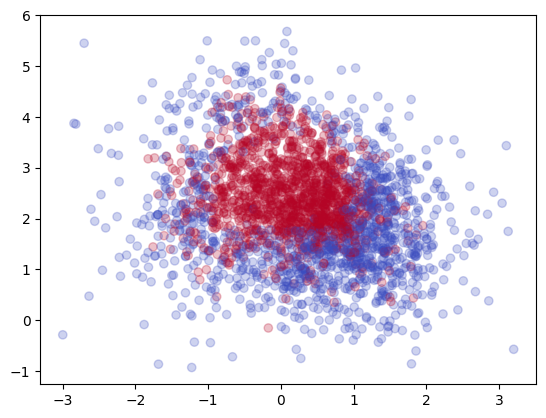

In [8]:
fig, ax = plt.subplots()
ax.scatter(x='plate_x', y='plate_z', c='type', data=aaron_judge, cmap=plt.cm.coolwarm, alpha=0.25)
plt.show()

In [9]:
training_set, validation_set = train_test_split(aaron_judge, random_state=1)

In [10]:
classifier = SVC(kernel='rbf')
classifier.fit(training_set[['plate_x', 'plate_z']], training_set['type'])

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### Visualization of SVM

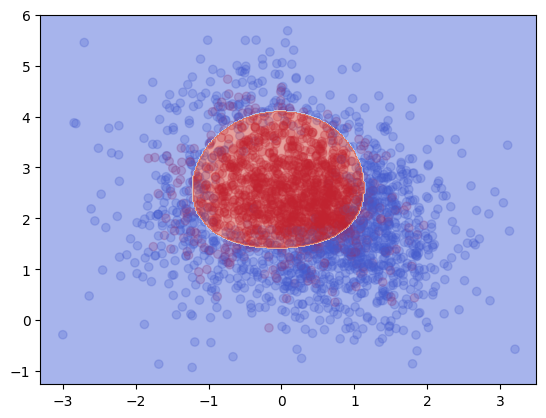

In [11]:
fig, ax = plt.subplots()
ax.scatter(x='plate_x', y='plate_z', c='type', data=aaron_judge, cmap=plt.cm.coolwarm, alpha=0.25)
draw_boundary(ax, classifier)
plt.show()

### Optimizing the SVM

In [12]:
acc = classifier.score(validation_set[['plate_x', 'plate_z']], validation_set['type'])
print(acc)

0.8295625942684767


In [13]:
classifier_2 = SVC(kernel='rbf', gamma=100, C=100)
classifier_2.fit(training_set[['plate_x', 'plate_z']], training_set['type'])

print("Train:", classifier_2.score(training_set[['plate_x', 'plate_z']], training_set['type']))
print("Validation:", classifier_2.score(validation_set[['plate_x', 'plate_z']], validation_set['type']))

Train: 0.974320241691843
Validation: 0.7933634992458521


High 'gamma' and 'C' resulted as overfitting

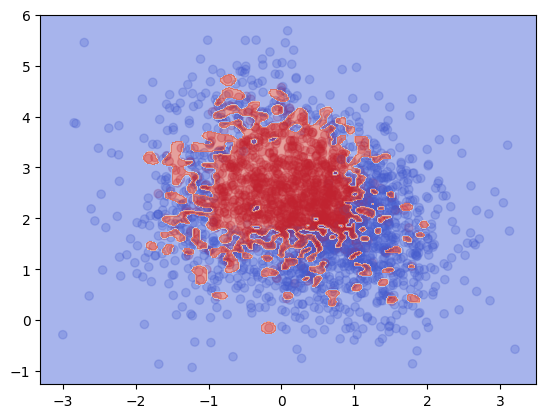

In [14]:
fig, ax = plt.subplots()
ax.scatter(x='plate_x', y='plate_z', c='type', data=aaron_judge, cmap=plt.cm.coolwarm, alpha=0.25)
draw_boundary(ax, classifier_2)
plt.show()

In [15]:
def find_best_params(training_set, validation_set):
    best_acc = 0
    best_gamma = None
    best_c = None

    for gamma in range(1, 16):
        for c in range(1, 16):
            clf = SVC(gamma=gamma, C=c)
            clf.fit(training_set[['plate_x', 'plate_z']], training_set['type'])
            acc = clf.score(validation_set[['plate_x', 'plate_z']], validation_set['type'])
            if acc > best_acc:
                best_gamma = gamma
                best_c = c
                best_acc = acc
    
    return {'gamma': best_gamma, 'c': best_c, 'accuracy': best_acc}

In [16]:
best_params = find_best_params(training_set, validation_set)
print('Gamma:', best_params['gamma'], "C:", best_params['c'], 'Accuracy:', best_params['accuracy'])

Gamma: 1 C: 12 Accuracy: 0.8355957767722474


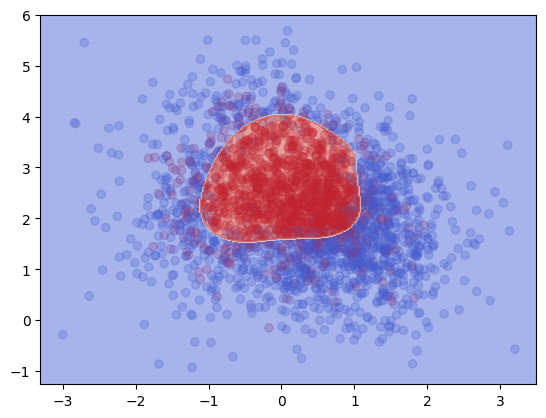

In [17]:
best_model = SVC(gamma=best_params['gamma'], C=best_params['c'])
best_model.fit(training_set[['plate_x', 'plate_z']], training_set['type'])

fig, ax = plt.subplots()
ax.scatter(x='plate_x', y='plate_z', c='type', data=aaron_judge, cmap=plt.cm.coolwarm, alpha=0.25)
draw_boundary(ax, best_model)
plt.show()

### Exploring Other Players

In [18]:
jose_altuve['type'] = jose_altuve['type'].map({'S': 1, 'B': 0})
jose_altuve = jose_altuve.dropna(subset = ['plate_x', 'plate_z', 'type'])

david_ortiz['type'] = david_ortiz['type'].map({'S': 1, 'B': 0})
david_ortiz = david_ortiz.dropna(subset = ['plate_x', 'plate_z', 'type'])

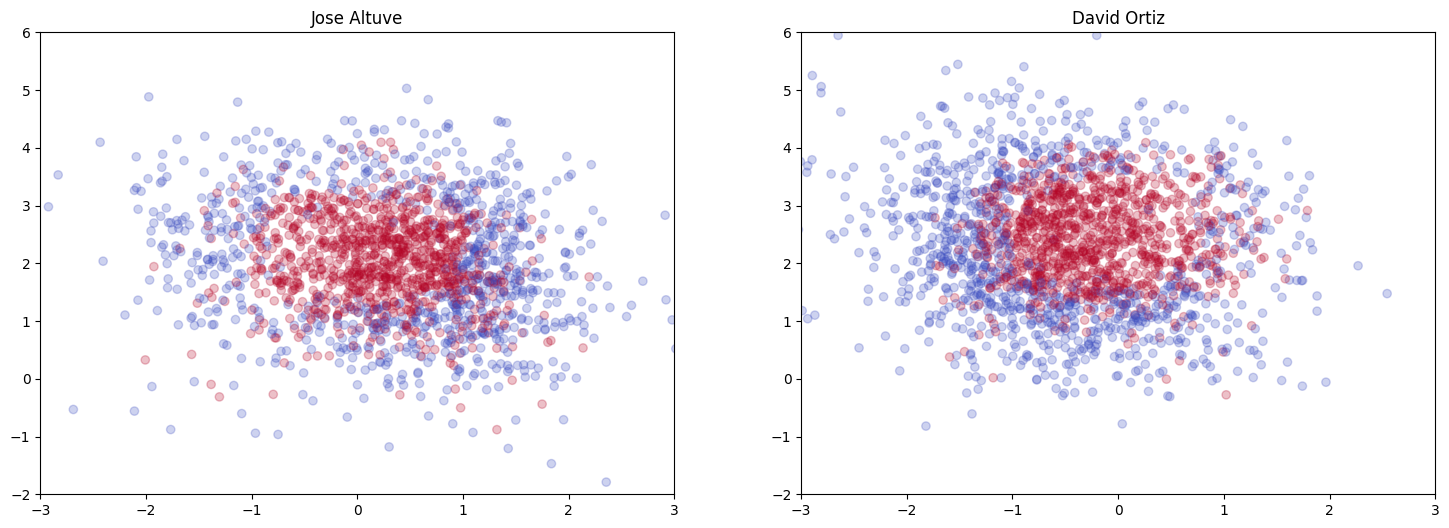

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

ax1.scatter(x='plate_x', y='plate_z', c='type', data=jose_altuve, cmap=plt.cm.coolwarm, alpha=0.25)
ax1.set_title('Jose Altuve')
ax1.set_ylim(-2, 6)
ax1.set_xlim(-3, 3)

ax2.scatter(x='plate_x', y='plate_z', c='type', data=david_ortiz, cmap=plt.cm.coolwarm, alpha=0.25)
ax2.set_title('David Ortiz')
ax2.set_ylim(-2, 6)
ax2.set_xlim(-3, 3)

plt.show()

In [20]:
training_set_alt, validation_set_alt = train_test_split(jose_altuve, random_state=1)
params_altuve = find_best_params(training_set_alt, validation_set_alt)

training_set_ort, validation_set_ort = train_test_split(david_ortiz, random_state=1)
params_ortiz = find_best_params(training_set_ort, validation_set_ort)

In [21]:
clf_altuve = SVC(gamma=params_altuve['gamma'], C=params_altuve['c'])
clf_altuve.fit(training_set_alt[['plate_x', 'plate_z']], training_set_alt['type'])

clf_ortiz = SVC(gamma=params_ortiz['gamma'], C=params_ortiz['c'])
clf_ortiz.fit(training_set_ort[['plate_x', 'plate_z']], training_set_ort['type'])

print(clf_altuve.score(validation_set_alt[['plate_x', 'plate_z']], validation_set_alt['type']))
print(clf_ortiz.score(validation_set_ort[['plate_x', 'plate_z']], validation_set_ort['type']))

0.8325892857142857
0.8385826771653543


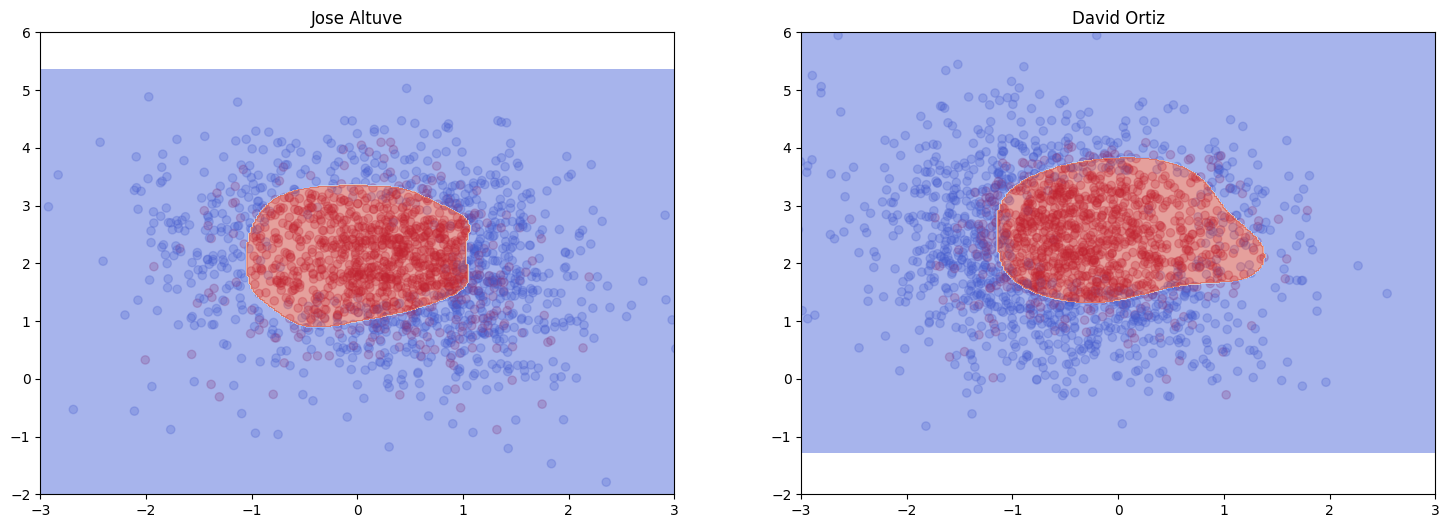

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

ax1.scatter(x='plate_x', y='plate_z', c='type', data=jose_altuve, cmap=plt.cm.coolwarm, alpha=0.25)
draw_boundary(ax1, clf_altuve)
ax1.set_ylim(-2, 6)
ax1.set_xlim(-3, 3)
ax1.set_title('Jose Altuve')

ax2.scatter(x='plate_x', y='plate_z', c='type', data=david_ortiz, cmap=plt.cm.coolwarm, alpha=0.25)
draw_boundary(ax2, clf_ortiz)
ax2.set_ylim(-2, 6)
ax2.set_xlim(-3, 3)
ax2.set_title('David Ortiz')

plt.show()

### Adding more features
'Strikes' feature was added

In [24]:
best_acc = 0
best_gamma = None
best_c = None

for gamma in range(1, 16):
    for c in range(1, 16):
        clf = SVC(gamma=gamma, C=c)
        clf.fit(training_set[['plate_x', 'plate_z', 'strikes']], training_set['type'])
        acc = clf.score(validation_set[['plate_x', 'plate_z', 'strikes']], validation_set['type'])
        if acc > best_acc:
            best_gamma = gamma
            best_c = c
            best_acc = acc

Previous Accuracy:

In [26]:
print(best_params['accuracy'])

0.8355957767722474


SVM model is improved with the addition of feature 'Strikes'

New Accuracy:

In [27]:
print(best_acc)

0.8506787330316742
